# Unsupervised Learning: Analisis Klasterisasi Stunting Balita Tingkat Regional

In [1]:
# Mengimpor pustaka utama untuk manipulasi data, klasterisasi, imputasi data kosong, dan pemetaan geografis
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
import folium
import json
import warnings
warnings.filterwarnings('ignore')

# Mengatur resolusi grafik matplotlib secara global ke 300 DPI untuk standar publikasi
mpl.rcParams['figure.dpi'] = 300
sns.set_theme(style='whitegrid')
print("Seluruh pustaka berhasil diimpor dengan konfigurasi visualisasi 300 DPI!")

Seluruh pustaka berhasil diimpor dengan konfigurasi visualisasi 300 DPI!


## 1. Memuat Dataset Status Gizi Regional Indonesia
Kita memuat dataset gizi kabupaten/kota dari file Excel dan memetakan datanya.

In [2]:
excel_path = 'dataset/Data-Status-Gizi-2018-2020-Kabupaten-Kota.xlsx'

# Membaca baris header secara spesifik pada baris index ke-4 (baris ke-5 pada Excel)
df_raw = pd.read_excel(excel_path, skiprows=4)

# Membersihkan dan menamai kolom-kolom utama
rename_dict = {
    df_raw.columns[1]: 'Provinsi',
    df_raw.columns[2]: 'Kabupaten_Kota',
    df_raw.columns[4]: 'Jumlah_Lahir',
    df_raw.columns[35]: 'Stunting_2019',
    df_raw.columns[37]: 'KEK_Ibu_Hamil',
    df_raw.columns[38]: 'Imunisasi_Dasar_Lengkap',
    df_raw.columns[39]: 'BBLR'
}
df_clean = df_raw.rename(columns=rename_dict)
keep_cols = list(rename_dict.values())
df_clean = df_clean[keep_cols]

# Menghapus baris kosong atau tidak memiliki nama provinsi
df_clean = df_clean.dropna(subset=['Provinsi', 'Kabupaten_Kota'])
df_clean['Provinsi'] = df_clean['Provinsi'].astype(str).str.strip()

print(f"Data mentah berhasil dimuat. Total baris: {df_clean.shape[0]}, Total kolom: {df_clean.shape[1]}")

Data mentah berhasil dimuat. Total baris: 514, Total kolom: 7


## 2. Inspeksi Awal Data (*Data Inspection*)
Menampilkan 5 baris pertama data bersih kabupaten/kota.

In [3]:
df_clean.head()

,Provinsi,Kabupaten_Kota,Jumlah_Lahir,Stunting_2019,KEK_Ibu_Hamil,Imunisasi_Dasar_Lengkap,BBLR
0,Aceh,Simeulue,2876.256,28.8,0.136555,0.542858,0.044060
1,Aceh,Aceh Singkil,5507.150,37.4,0.108781,0.567045,0.058867
2,Aceh,Aceh Selatan,5964.009,30.9,0.215570,0.251362,0.136317
3,Aceh,Aceh Tenggara,9511.544,43.4,0.045437,0.115863,0.024592
4,Aceh,Aceh Timur,11246.628,24.6,0.184270,0.124985,0.133027


### 2.1 Informasi Tipe Data dan Kelengkapan
Mengecek tipe data tiap kolom dan memeriksa keberadaan nilai kosong.

In [4]:
df_clean.info()
print("\nJumlah baris duplikat:", df_clean.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Provinsi                 514 non-null    str    
 1   Kabupaten_Kota           514 non-null    str    
 2   Jumlah_Lahir             514 non-null    float64
 3   Stunting_2019            514 non-null    float64
 4   KEK_Ibu_Hamil            453 non-null    float64
 5   Imunisasi_Dasar_Lengkap  503 non-null    float64
 6   BBLR                     474 non-null    float64
dtypes: float64(5), str(2)
memory usage: 28.2 KB

Jumlah baris duplikat: 0


## 3. Agregasi Berbobot Tingkat Provinsi (*Birth-Weighted Aggregation*)
Untuk mendapatkan prevalensi yang valid di tingkat provinsi, kita melakukan agregasi rata-rata tertimbang (*weighted average*) menggunakan jumlah kelahiran bayi di tiap kabupaten/kota sebagai bobot.

In [5]:
def calculate_weighted_avg(group, value_col, weight_col):
    values = group[value_col].astype(float)
    weights = group[weight_col].astype(float)
    valid = ~(values.isna() | weights.isna())
    if not valid.any() or weights[valid].sum() == 0:
        return np.nan
    return np.average(values[valid], weights=weights[valid])

prov_data = []
grouped = df_clean.groupby('Provinsi')

for prov_name, group in grouped:
    total_births = group['Jumlah_Lahir'].sum(min_count=1)
    stunting_19 = calculate_weighted_avg(group, 'Stunting_2019', 'Jumlah_Lahir')
    kek = calculate_weighted_avg(group, 'KEK_Ibu_Hamil', 'Jumlah_Lahir')
    idl = calculate_weighted_avg(group, 'Imunisasi_Dasar_Lengkap', 'Jumlah_Lahir')
    bblr = calculate_weighted_avg(group, 'BBLR', 'Jumlah_Lahir')

    prov_data.append({
        'Provinsi': prov_name,
        'Jumlah_Lahir': total_births,
        'Stunting_2019': stunting_19,
        'KEK_Ibu_Hamil': kek,
        'Imunisasi_Dasar_Lengkap': idl,
        'BBLR': bblr
    })

df_prov = pd.DataFrame(prov_data)
df_prov.head()

,Provinsi,Jumlah_Lahir,Stunting_2019,KEK_Ibu_Hamil,Imunisasi_Dasar_Lengkap,BBLR
0,Aceh,171718.723,35.392169,0.121565,0.210334,0.067376
1,Bali,45182.469,15.972776,0.129219,0.917864,0.060494
2,Bangka Belitung,24715.078,20.305718,0.164611,0.741730,0.056877
3,Banten,254076.461,26.583807,0.183923,0.419527,0.052752
4,Bengkulu,44151.077,27.704721,0.144251,0.623825,0.053565


## 4. Imputasi Cerdas Menggunakan KNN Imputer
Menggantikan nilai kosong pada variabel regional dengan algoritma **KNN Imputer** (K=5) berdasarkan kemiripan profil gizi antar provinsi.

In [6]:
# Mengecek jumlah nilai kosong tingkat provinsi sebelum imputasi
print("Nilai kosong sebelum KNN Imputation:")
print(df_prov.isnull().sum())

# Menerapkan KNN Imputer
imputer = KNNImputer(n_neighbors=5)
numeric_cols = ['Jumlah_Lahir', 'Stunting_2019', 'KEK_Ibu_Hamil', 'Imunisasi_Dasar_Lengkap', 'BBLR']
df_prov[numeric_cols] = imputer.fit_transform(df_prov[numeric_cols])

print("\nNilai kosong setelah KNN Imputation:")
print(df_prov.isnull().sum())

Nilai kosong sebelum KNN Imputation:
Provinsi                   0
Jumlah_Lahir               0
Stunting_2019              0
KEK_Ibu_Hamil              0
Imunisasi_Dasar_Lengkap    0
BBLR                       0
dtype: int64

Nilai kosong setelah KNN Imputation:
Provinsi                   0
Jumlah_Lahir               0
Stunting_2019              0
KEK_Ibu_Hamil              0
Imunisasi_Dasar_Lengkap    0
BBLR                       0
dtype: int64


## 5. Analisis Eksplorasi Data (EDA) - 300 DPI
Menampilkan hubungan korelasi indikator regional dan pola distribusinya. 

**Catatan Akademis**: Variabel stunting tahun 2018 sengaja dihilangkan untuk menghindari multikolinearitas ekstrem ($r > 0.90$) yang dapat mendominasi K-Means dan mendistorsi hasil klasterisasi regional.

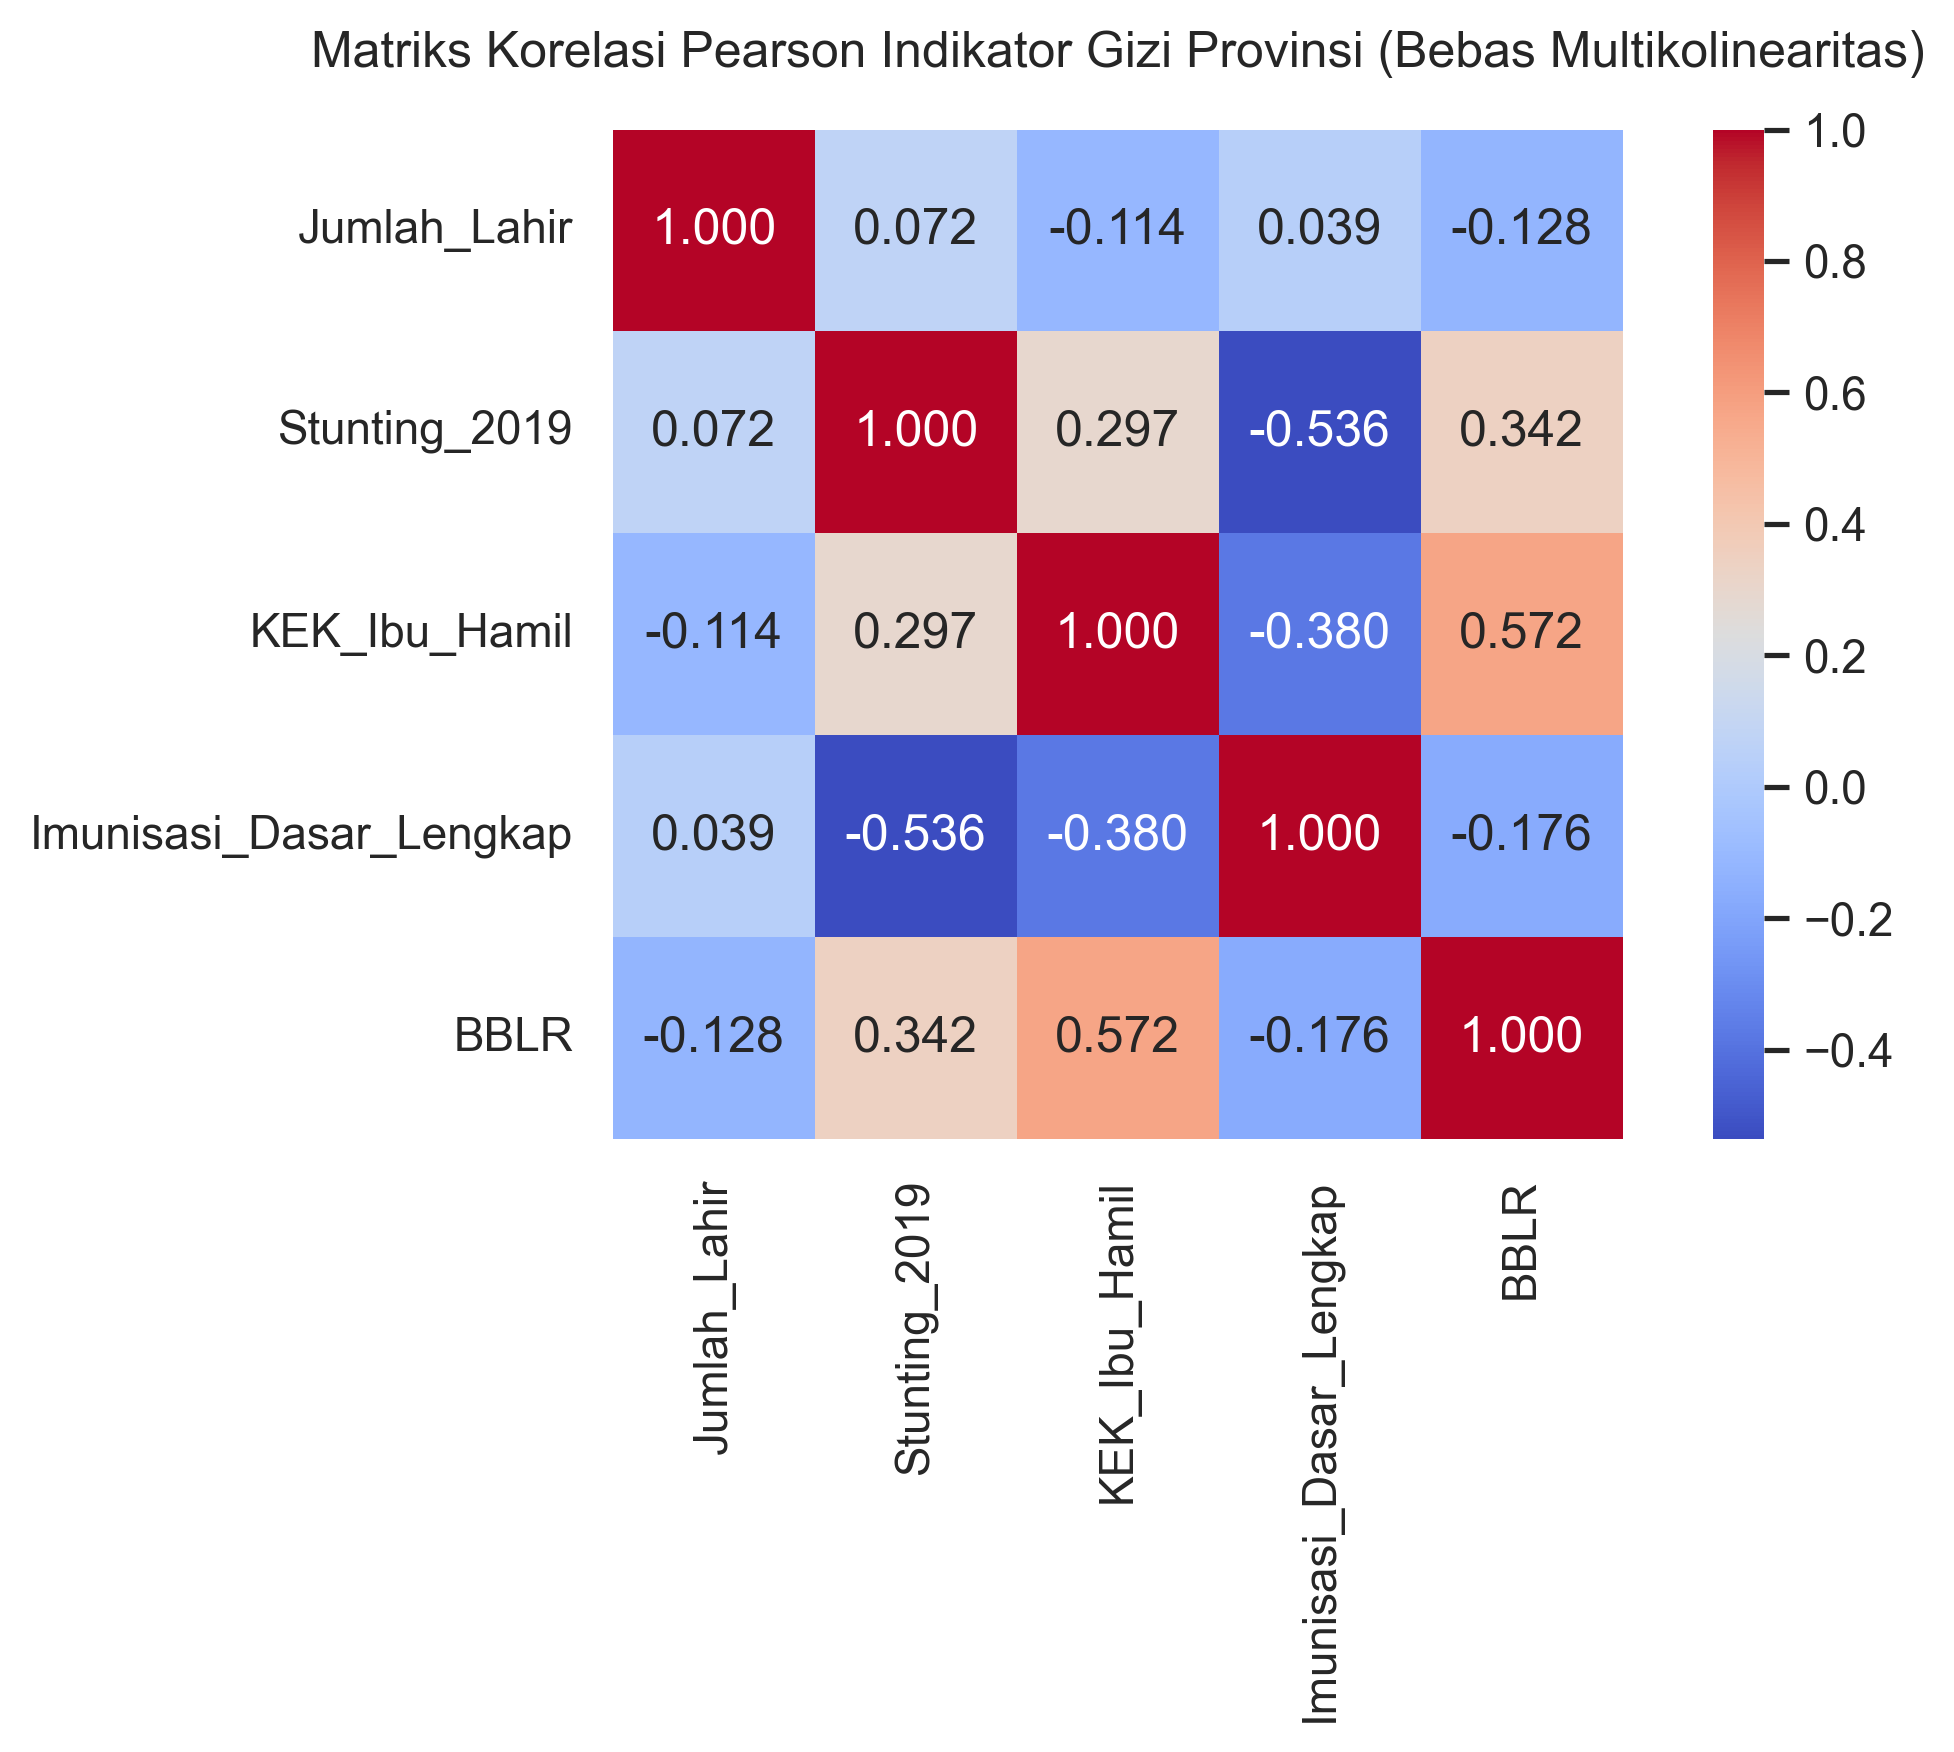

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_prov[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.3f', square=True)
plt.title('Matriks Korelasi Pearson Indikator Gizi Provinsi (Bebas Multikolinearitas)', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('results/korelasi_gizi_regional.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Standardisasi Fitur
Melakukan standardisasi nilai fitur numerik menggunakan `StandardScaler` agar memiliki rata-rata 0 dan variansi 1.

In [8]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_prov[numeric_cols])
df_scaled = pd.DataFrame(scaled_features, columns=numeric_cols, index=df_prov.index)
df_scaled.describe()

,Jumlah_Lahir,Stunting_2019,KEK_Ibu_Hamil,Imunisasi_Dasar_Lengkap,BBLR
count,3.400000e+01,3.400000e+01,3.400000e+01,3.400000e+01,3.400000e+01
mean,-1.567374e-16,2.644943e-16,-2.955152e-16,4.310278e-16,1.697988e-16
std,1.015038e+00,1.015038e+00,1.015038e+00,1.015038e+00,1.015038e+00
min,-7.128840e-01,-2.106069e+00,-1.932952e+00,-2.109270e+00,-2.058063e+00
25%,-5.785131e-01,-5.927438e-01,-6.100996e-01,-6.947409e-01,-5.831697e-01
50%,-3.706311e-01,3.629209e-02,-1.972546e-01,1.125503e-01,-1.611818e-01
75%,2.270597e-02,6.015594e-01,2.805482e-01,7.669896e-01,5.452448e-01
max,3.837443e+00,2.721125e+00,2.898069e+00,2.179759e+00,2.937407e+00


## 7. Penentuan Jumlah Klaster Optimal (300 DPI)
Kita menganalisis jumlah K terbaik menggunakan metode Elbow dan Silhouette Coefficient.

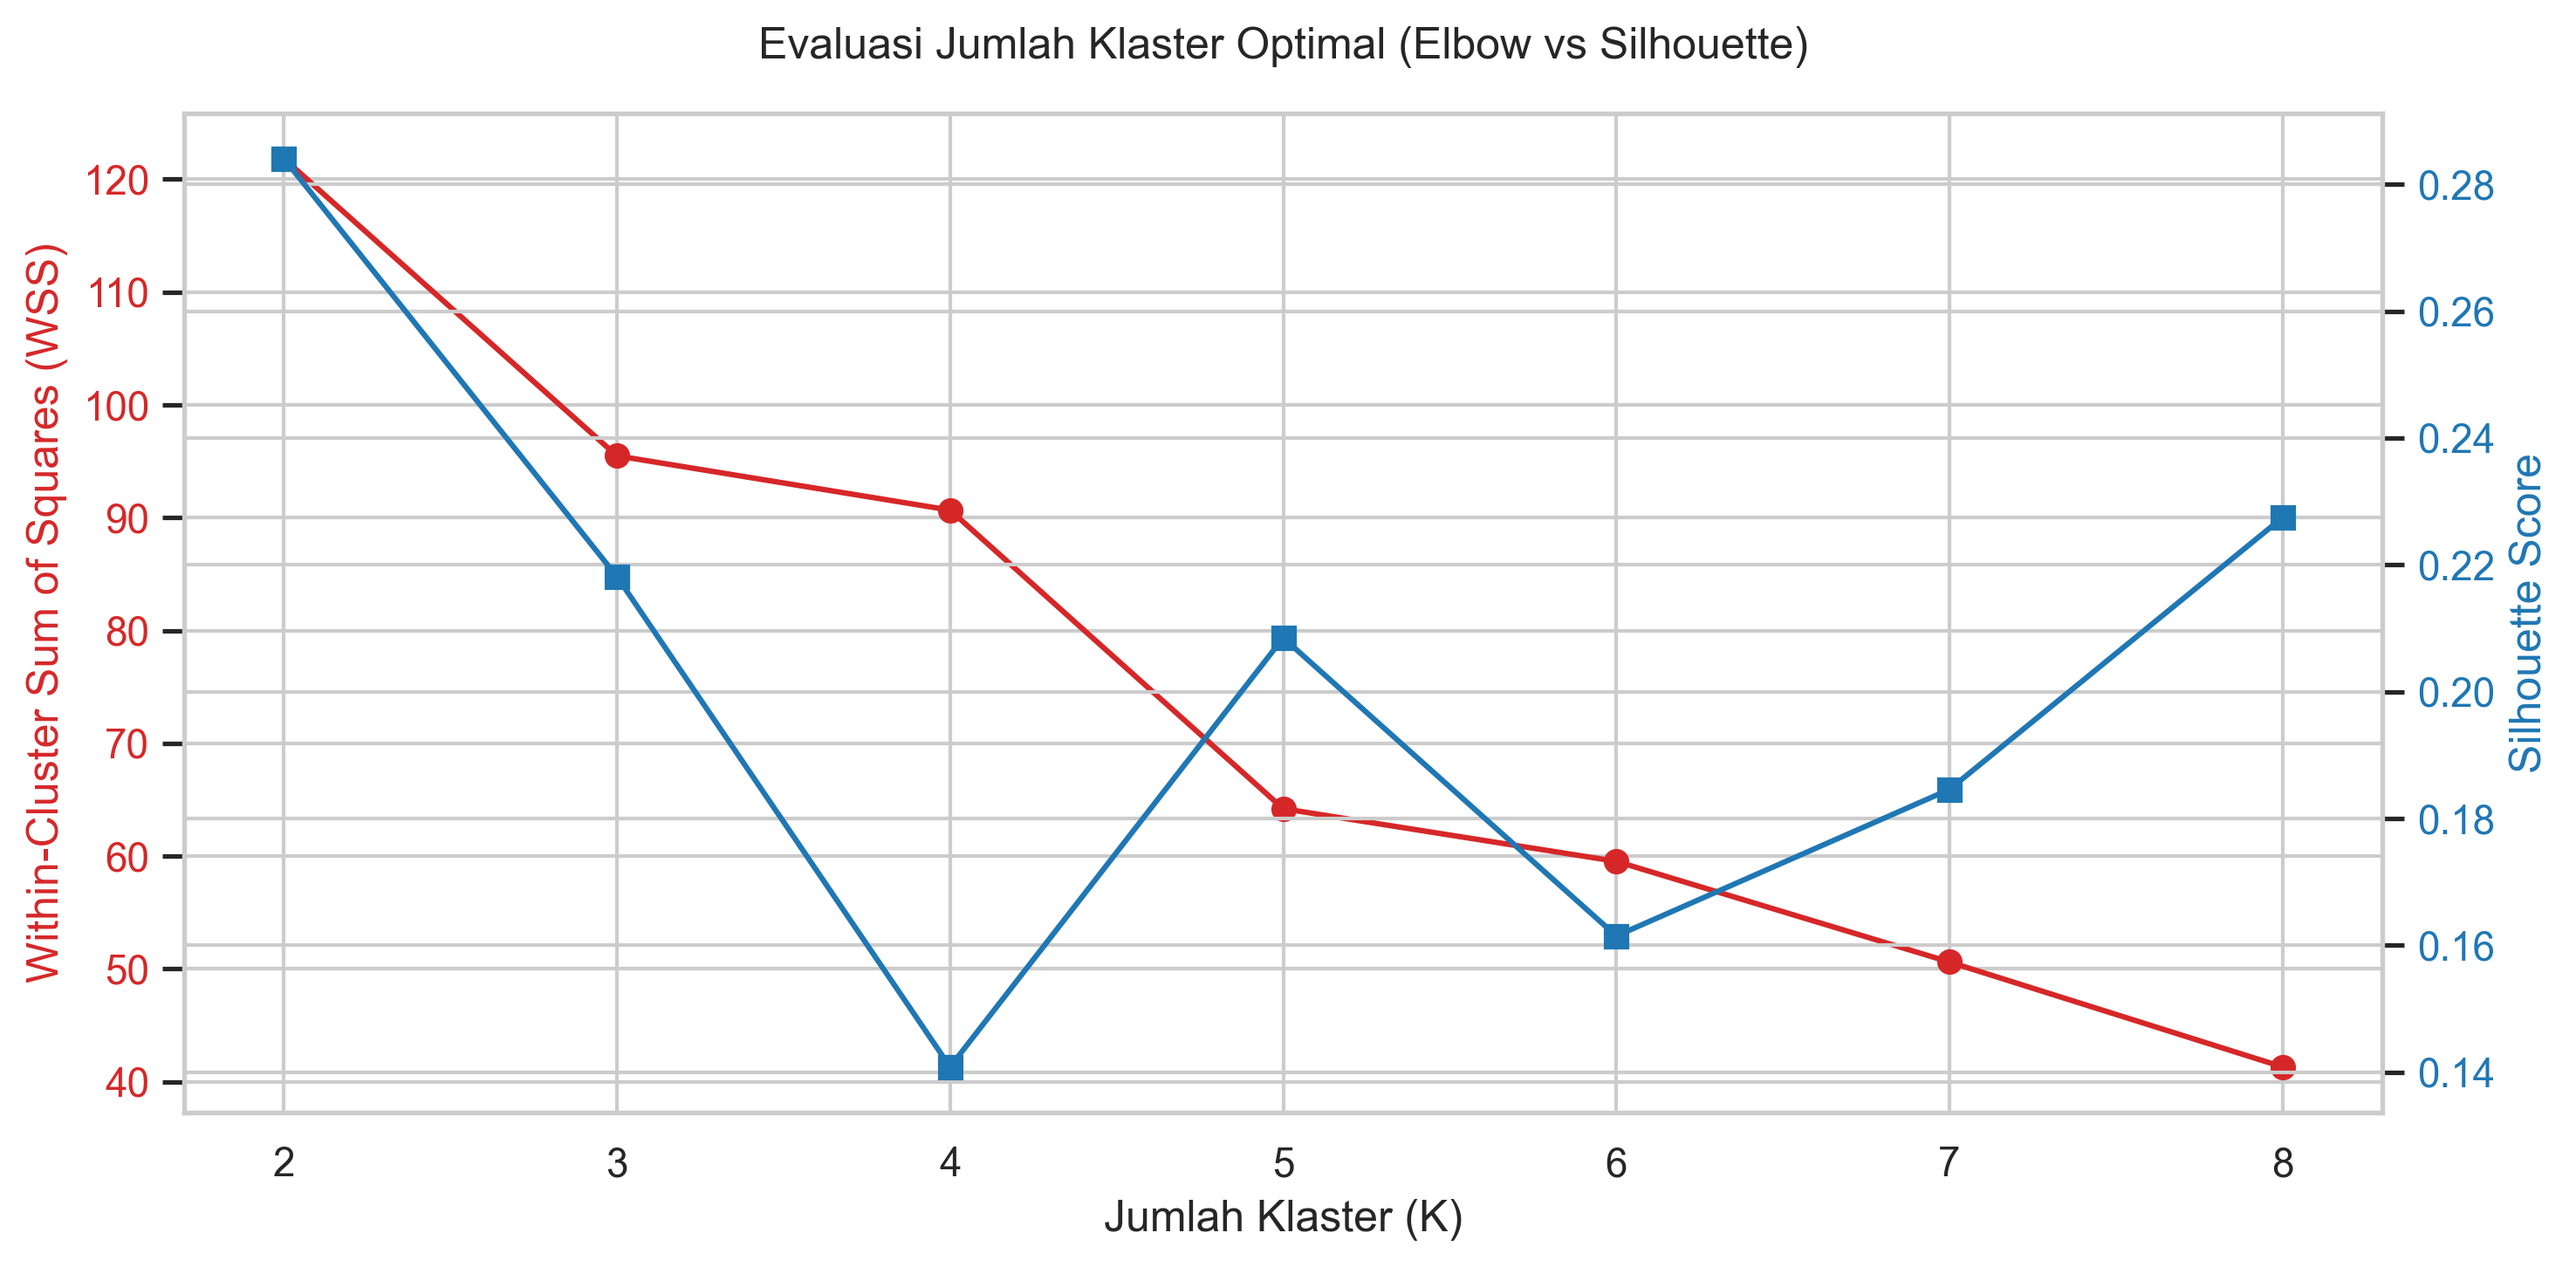

In [9]:
wss = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df_scaled)
    wss.append(km.inertia_)
    sil_scores.append(silhouette_score(df_scaled, labels))

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Jumlah Klaster (K)')
ax1.set_ylabel('Within-Cluster Sum of Squares (WSS)', color=color)
ax1.plot(K_range, wss, 'o-', color=color, label='WSS')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, sil_scores, 's-', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Jumlah Klaster Optimal (Elbow vs Silhouette)', fontsize=12, pad=15)
fig.tight_layout()
plt.savefig('results/evaluasi_k_optimal.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Pemodelan Klaster K-Means, GMM, dan Hierarchical
Menerapkan algoritma K-Means, Gaussian Mixture Model, dan Hierarchical dengan K=3.

In [10]:
# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df_prov['Klaster_KMeans'] = kmeans.fit_predict(df_scaled)

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=42)
df_prov['Klaster_GMM'] = gmm.fit_predict(df_scaled)

# Hierarchical Agglomerative
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_prov['Klaster_HC'] = hc.fit_predict(df_scaled)

print("Semua algoritma clustering berhasil diaplikasikan!")

Semua algoritma clustering berhasil diaplikasikan!


### 8.1 Visualisasi Dendrogram Hierarchical Clustering (300 DPI)
Menampilkan susunan hirarki pengelompokan provinsi berdasarkan keterkaitan variabel antropometri gizi.

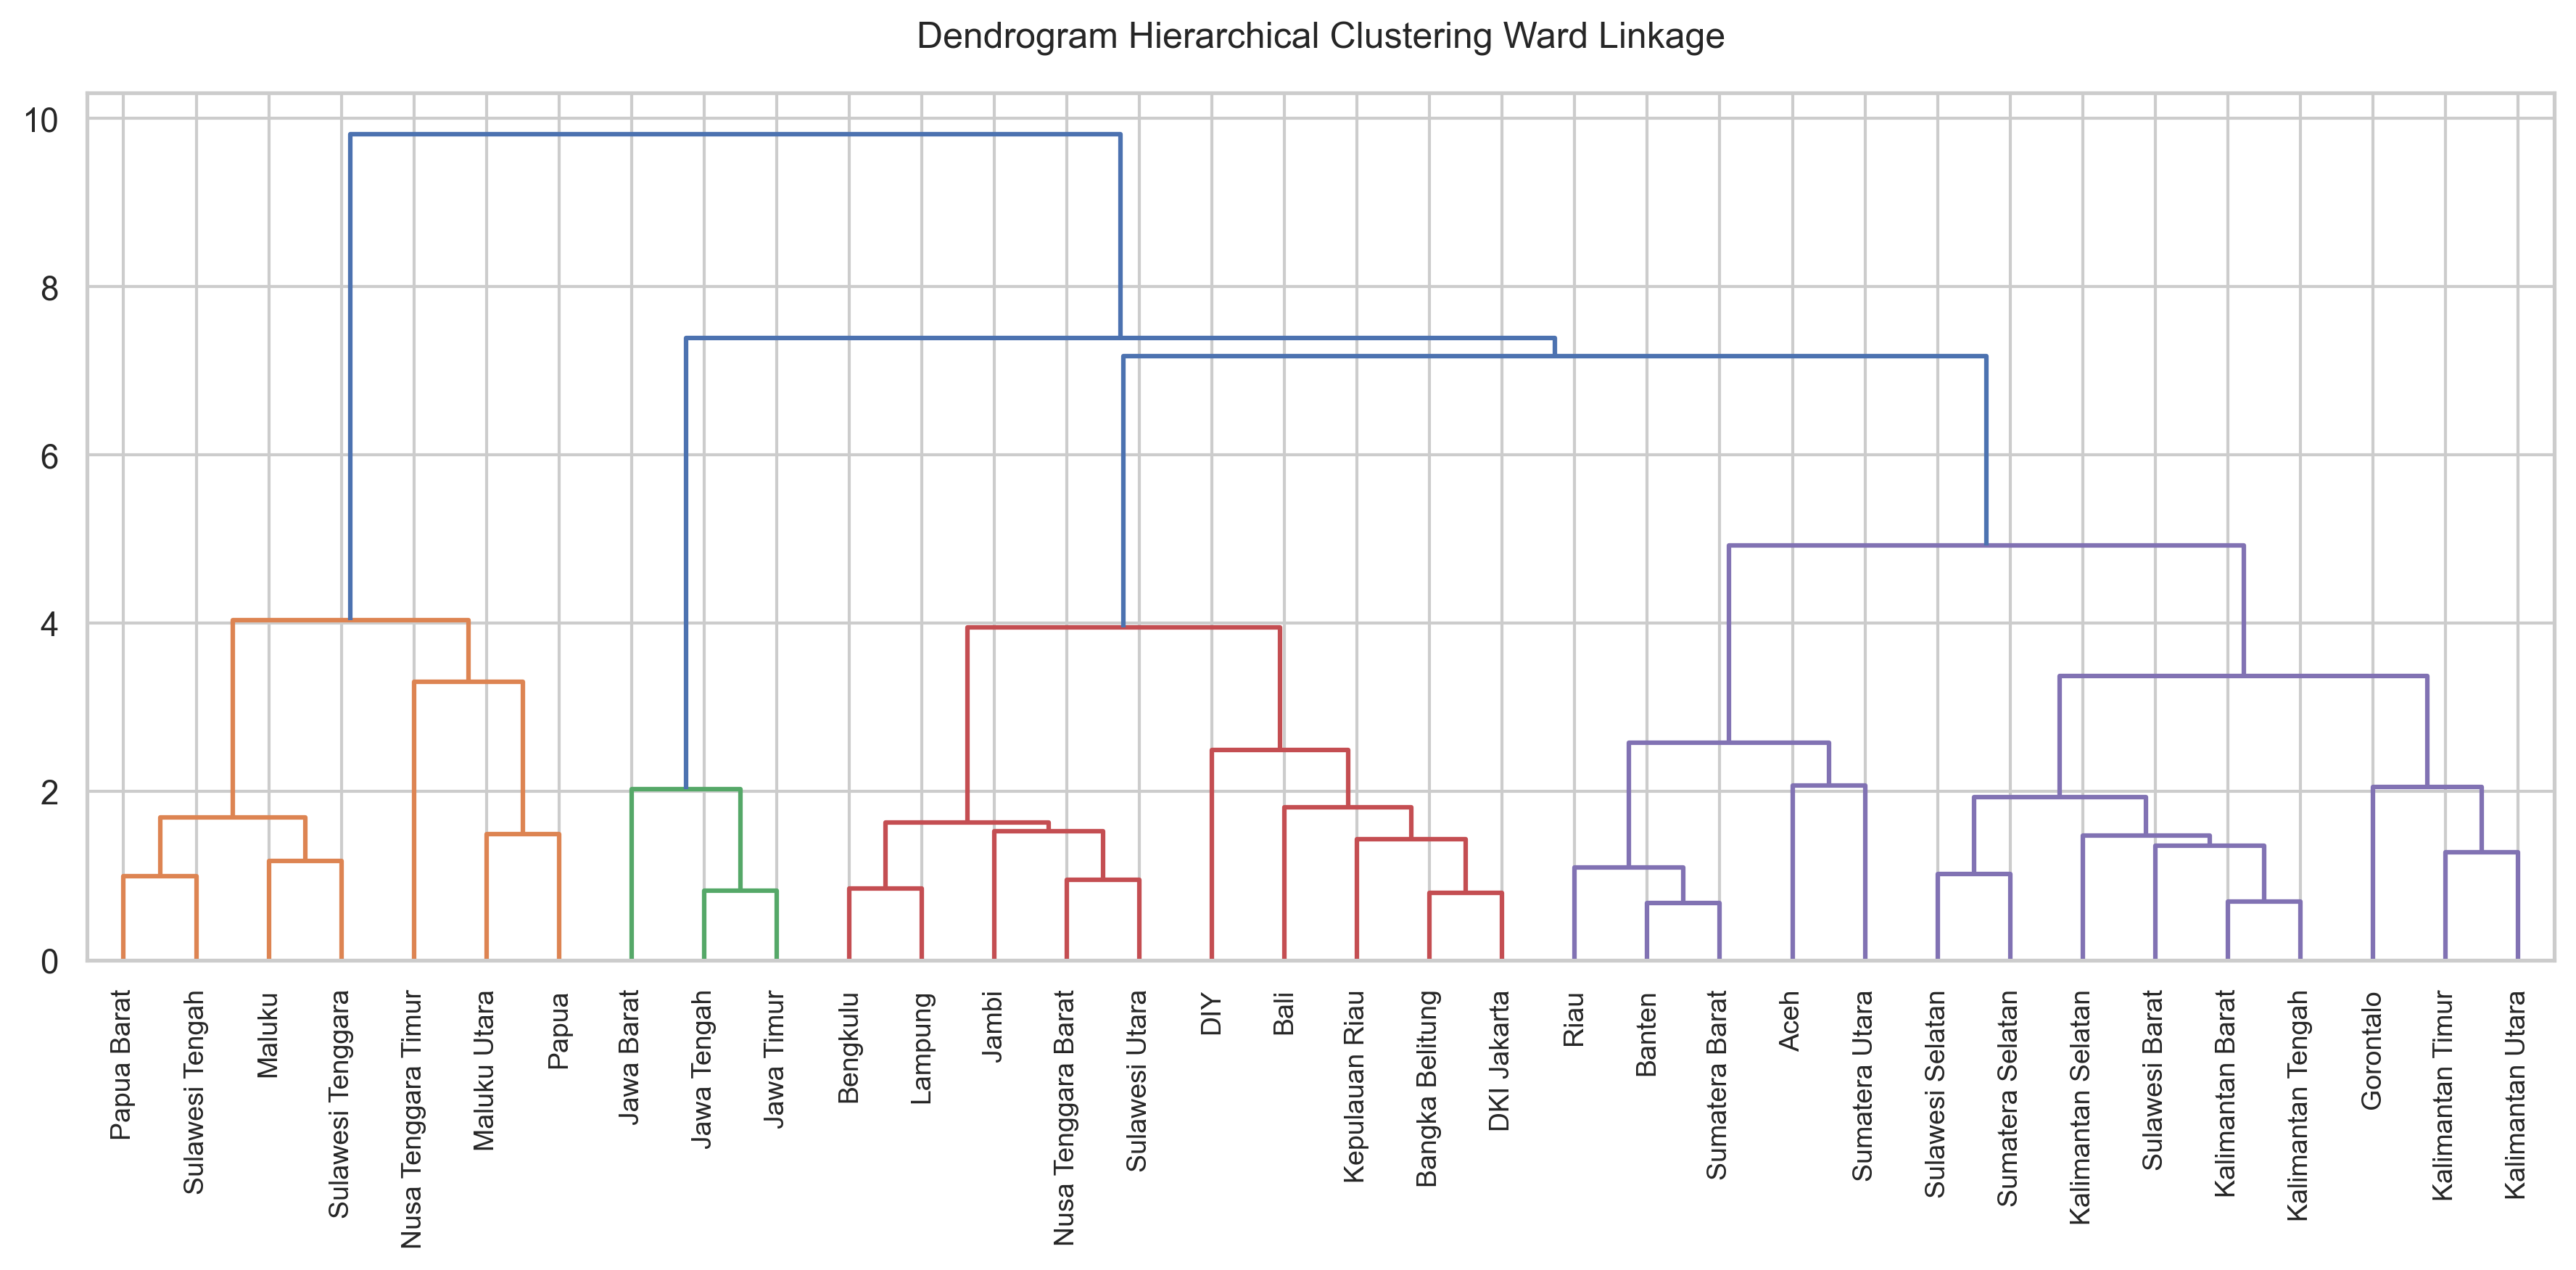

In [11]:
plt.figure(figsize=(12, 6))
linked = linkage(df_scaled, method='ward')
dendrogram(linked, labels=df_prov['Provinsi'].values, leaf_rotation=90, leaf_font_size=9)
plt.title('Dendrogram Hierarchical Clustering Ward Linkage', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('results/dendrogram_gizi_regional.png', dpi=300, bbox_inches='tight')
plt.show()

### 8.2 Analisis Konsistensi Klaster (Adjusted Rand Index)
Mengukur derajat kesamaan hasil pengelompokan antar ketiga model secara kuantitatif.

In [12]:
ari_km_gmm = adjusted_rand_score(df_prov['Klaster_KMeans'], df_prov['Klaster_GMM'])
ari_km_hc = adjusted_rand_score(df_prov['Klaster_KMeans'], df_prov['Klaster_HC'])
ari_gmm_hc = adjusted_rand_score(df_prov['Klaster_GMM'], df_prov['Klaster_HC'])

print(f"Adjusted Rand Index (K-Means vs GMM): {ari_km_gmm:.4f}")
print(f"Adjusted Rand Index (K-Means vs Hierarchical): {ari_km_hc:.4f}")
print(f"Adjusted Rand Index (GMM vs Hierarchical): {ari_gmm_hc:.4f}")

Adjusted Rand Index (K-Means vs GMM): 0.9057
Adjusted Rand Index (K-Means vs Hierarchical): 0.3818
Adjusted Rand Index (GMM vs Hierarchical): 0.3169


### 8.3 Evaluasi Metrik Kualitas Klaster
Menghitung skor Silhouette, Davies-Bouldin, dan Calinski-Harabasz untuk ketiga algoritma.

In [13]:
metrics = {}
for name, col in [('K-Means', 'Klaster_KMeans'), ('GMM', 'Klaster_GMM'), ('Hierarchical', 'Klaster_HC')]:
    sil = silhouette_score(df_scaled, df_prov[col])
    db = davies_bouldin_score(df_scaled, df_prov[col])
    ch = calinski_harabasz_score(df_scaled, df_prov[col])
    metrics[name] = {'Silhouette Score': sil, 'Davies-Bouldin Index': db, 'Calinski-Harabasz Index': ch}

df_metrics = pd.DataFrame(metrics).T
df_metrics

,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
K-Means,0.218165,1.272105,12.096479
GMM,0.199484,1.323591,11.343325
Hierarchical,0.319915,0.987706,12.378914


## 9. Profiling Klaster Provinsi Terpilih
Menyajikan karakteristik rata-rata indikator gizi tiap kelompok klaster (K-Means).

In [14]:
profile = df_prov.groupby('Klaster_KMeans')[numeric_cols].mean()
print("Profil Rata-rata Variabel Indikator Gizi per Klaster:")
profile

Profil Rata-rata Variabel Indikator Gizi per Klaster:


,Jumlah_Lahir,Stunting_2019,KEK_Ibu_Hamil,Imunisasi_Dasar_Lengkap,BBLR
Klaster_KMeans,,,,,
0,248951.275579,30.722239,0.156987,0.543519,0.062335
1,89894.044714,33.749914,0.329735,0.412994,0.083321
2,68014.153750,20.681462,0.190328,0.720483,0.059486


### 9.1 Visualisasi Sebaran Klaster: Stunting vs KEK Ibu Hamil (300 DPI)
Memvisualisasikan pemisahan antar klaster berdasarkan dua fitur terpenting.

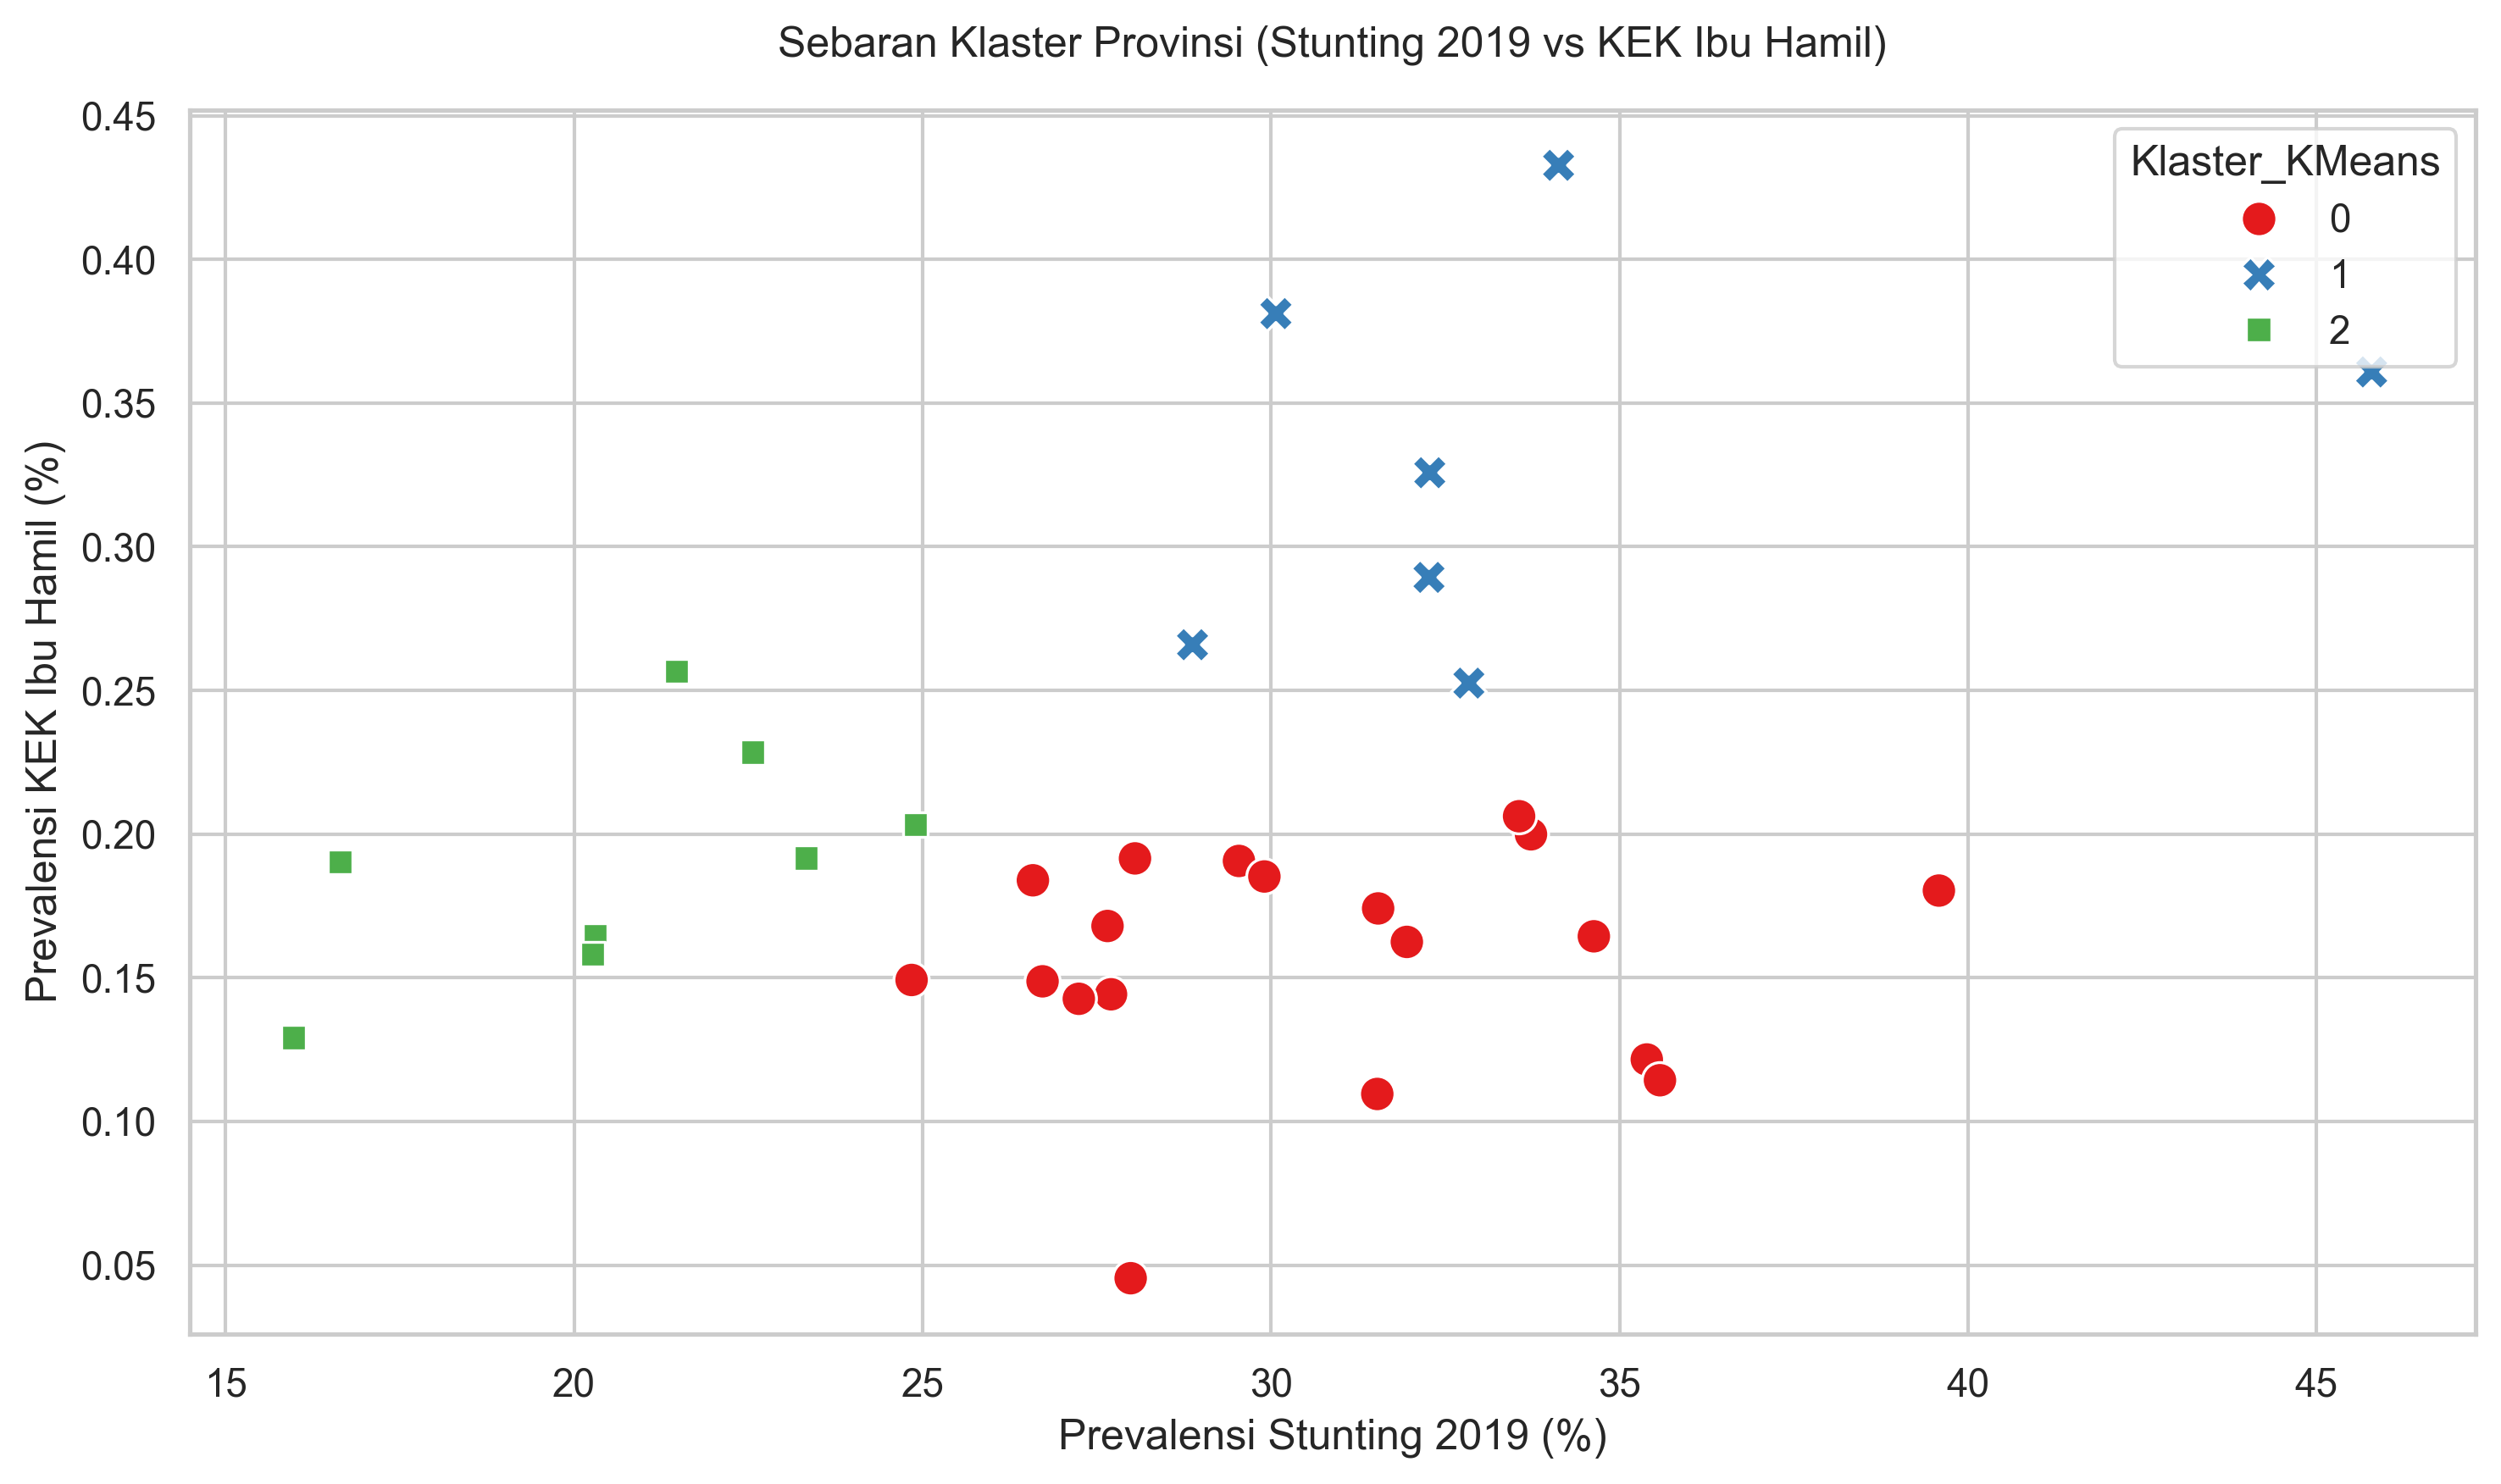

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_prov,
    x='Stunting_2019',
    y='KEK_Ibu_Hamil',
    hue='Klaster_KMeans',
    palette='Set1',
    s=100,
    style='Klaster_KMeans'
)
plt.title('Sebaran Klaster Provinsi (Stunting 2019 vs KEK Ibu Hamil)', fontsize=12, pad=15)
plt.xlabel('Prevalensi Stunting 2019 (%)')
plt.ylabel('Prevalensi KEK Ibu Hamil (%)')
plt.tight_layout()
plt.savefig('results/scatter_klaster_regional.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Pemetaan Spasial Spasial Provinsi Indonesia (Folium)
Menggambar peta choropleth interaktif provinsi berdasarkan hasil klasterisasi K-Means gizi buruk.

In [16]:
# Memuat batas administrasi spasial provinsi Indonesia
with open('dataset/indonesia-province-simple.json', 'r', encoding='utf-8') as f:
    geojson_data = json.load(f)

# Standarisasi nama provinsi agar cocok dengan nama di GeoJSON
geojson_provs = [feature['properties']['Propinsi'] for feature in geojson_data['features']]

prov_map = {
    'DKI Jakarta': 'Jakarta Raya',
    'Bangka Belitung': 'Kepulauan Bangka Belitung',
    'DI Yogyakarta': 'Yogyakarta',
    'Nanggroe Aceh Darussalam': 'Aceh'
}
df_prov['Provinsi_Map'] = df_prov['Provinsi'].replace(prov_map)

# Membuat peta dasar berpusat di koordinat tengah Indonesia
m = folium.Map(location=[-2.5, 118], zoom_start=5)

# Membuat layer Choropleth
folium.Choropleth(
    geo_data=geojson_data,
    name='choropleth',
    data=df_prov,
    columns=['Provinsi_Map', 'Klaster_KMeans'],
    key_on='feature.properties.Propinsi',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Klaster Gizi (0=Baik, 1=Sedang, 2=Kritis)'
).add_to(m)

# Menyimpan peta
m.save('results/indonesia_stunting_map.html')
print("Peta Choropleth geografis interaktif berhasil disimpan sebagai results/indonesia_stunting_map.html!")

Peta Choropleth geografis interaktif berhasil disimpan sebagai results/indonesia_stunting_map.html!
